# LightFM Hyperparameter Tuning

## Роль notebook

Этот notebook продолжает `02b_lightfm_feature_engineering.ipynb`.
Здесь мы уже не меняем признаки объектов.
Цель notebook: понять, можно ли получить `LightFM`, сопоставимый с `ALS` или лучше него, за счёт настройки гиперпараметров на лучшем feature set из `02b`.


## План

- взять сильнейший feature set из `02b` как фиксированную базу;
- обучить reference-версию `ALS`;
- запустить `Optuna` для поиска хорошей конфигурации `LightFM` по `validation`;
- посмотреть встроенные графики истории оптимизации и важности гиперпараметров;
- сравнить tuned-модель с `ALS` и baseline-конфигурацией `LightFM` сначала на `validation`, а затем на held-out `test`.


## Требование к окружению

Этот notebook должен использовать реальные библиотеки `lightfm`, `optuna` и `plotly`.
Если `optuna` или `plotly` не установлены, выполнение нужно остановить и сначала установить зависимости, например `pip install optuna plotly`.


In [25]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", message="LightFM was compiled without OpenMP support.*", category=UserWarning)


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с папкой src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("ggplot")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero
SRC_DIR: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/src


In [26]:
try:
    from lightfm import LightFM
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Библиотека `lightfm` не установлена. Установите её в окружение проекта (`pip install lightfm`) и перезапустите notebook."
    ) from exc

try:
    import optuna
    from optuna.samplers import TPESampler
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Библиотека `optuna` не установлена. Установите её в окружение проекта (`pip install optuna`) и перезапустите notebook."
    ) from exc

try:
    import plotly
    from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Библиотека `plotly` не установлена. Она нужна для встроенных графиков `Optuna`. Установите её (`pip install plotly`) и перезапустите notebook."
    ) from exc

from recsys_basics.advanced.als import ImplicitALSRecommender
from recsys_basics.advanced.lightfm import (
    LightFMHybridRecommender,
    build_item_decade_feature_map,
    build_item_genre_feature_map,
    merge_item_feature_maps,
)
from recsys_basics.basic.popularity import (
    PopularityRecommender,
    build_seen_items_map,
    filter_positive_explicit_feedback,
)
from recsys_basics.data import build_explicit_interactions, get_movielens_data_dir, load_movielens_frames
from recsys_basics.metrics import evaluate_ranking_metrics
from recsys_basics.split import assert_no_user_time_leakage, leave_last_two_out_split

DATA_DIR = get_movielens_data_dir()
MIN_RATING = 4.0
TOP_K = 10
N_TRIALS = 30

frames = load_movielens_frames(DATA_DIR)
interactions_df = build_explicit_interactions(frames.ratings)
movies_df = frames.movies.rename(columns={"movieId": "item_id"}).copy()

print(f"Interactions loaded: {len(interactions_df):,}")
print(f"Movies loaded: {len(movies_df):,}")
print(f"Optuna trials planned: {N_TRIALS}")


Interactions loaded: 100,836
Movies loaded: 9,742
Optuna trials planned: 30


## Постановка остаётся фиксированной

Чтобы tuning был честным, сохраняем:

- тот же `MovieLens latest small`;
- тот же `implicit` сигнал;
- тот же `train / validation / test` split;
- тот же feature set, который оказался сильнейшим в `02b`.

Здесь `train / validation / test` делятся не по фиксированным процентам, а по временной логике на пользователя.
Поэтому `validation` и `test` получаются маленькими по числу строк, но это нормально: их задача не занять условные `10%` датасета, а дать по одному честному отложенному примеру на каждого пользователя.

Меняем только гиперпараметры `LightFM`.

При этом роли наборов теперь разные:

- `train` используется для обучения моделей;
- `validation` используется для выбора лучшей конфигурации в `Optuna`;
- `test` остаётся held-out набором для финальной проверки после tuning.


In [27]:
positive_df = filter_positive_explicit_feedback(interactions_df, min_rating=MIN_RATING)
split_result = leave_last_two_out_split(positive_df, min_user_interactions=3)
train_df = split_result.train
val_df = split_result.validation
test_df = split_result.test

assert_no_user_time_leakage(train_df, val_df)
assert_no_user_time_leakage(pd.concat([train_df, val_df], ignore_index=True), test_df)

split_summary = pd.DataFrame(
    {
        "metric": [
            "train_rows",
            "validation_rows",
            "test_rows",
            "train_users",
            "validation_users",
            "test_users",
            "train_items",
            "validation_items",
            "test_items",
        ],
        "value": [
            len(train_df),
            len(val_df),
            len(test_df),
            train_df["user_id"].nunique(),
            val_df["user_id"].nunique(),
            test_df["user_id"].nunique(),
            train_df["item_id"].nunique(),
            val_df["item_id"].nunique(),
            test_df["item_id"].nunique(),
        ],
    }
)

display(split_summary)


,metric,value
0,train_rows,47363
1,validation_rows,608
2,test_rows,608
3,train_users,608
4,validation_users,608
5,test_users,608
6,train_items,6227
7,validation_items,488
8,test_items,503


In [28]:
genre_feature_map = build_item_genre_feature_map(movies_df)
decade_feature_map = build_item_decade_feature_map(movies_df)

# По итогам 02b именно связка genres + decade дала лучший общий результат,
# поэтому для tuning фиксируем этот feature set и меняем только гиперпараметры.
tuning_feature_map = merge_item_feature_maps(
    genre_feature_map,
    decade_feature_map,
)

feature_summary = pd.DataFrame(
    {
        "metric": ["genre_tokens", "decade_tokens", "tuning_feature_tokens"],
        "value": [
            len({token for tokens in genre_feature_map.values() for token in tokens}),
            len({token for tokens in decade_feature_map.values() for token in tokens}),
            len({token for tokens in tuning_feature_map.values() for token in tokens}),
        ],
    }
)

seen_items_map = build_seen_items_map(train_df)
val_user_ids = sorted(val_df["user_id"].unique().tolist())
test_user_ids = sorted(test_df["user_id"].unique().tolist())

display(feature_summary)


,metric,value
0,genre_tokens,20
1,decade_tokens,12
2,tuning_feature_tokens,32


In [29]:
popularity_model = PopularityRecommender().fit(train_df)
als_model = ImplicitALSRecommender(
    n_factors=16,
    n_iterations=8,
    regularization=0.1,
    alpha=20.0,
    random_state=42,
).fit(train_df)


def summarize_metrics(
    eval_df: pd.DataFrame,
    recommendations: pd.DataFrame,
    name: str,
    k: int = TOP_K,
) -> dict[str, float | str]:
    metrics_df = evaluate_ranking_metrics(eval_df, recommendations, k=k)
    unique_items = recommendations["item_id"].nunique() if not recommendations.empty else 0
    catalog_items = train_df["item_id"].nunique()
    summary = {"model": name}
    for column in metrics_df.columns:
        if column == "user_id":
            continue
        summary[column] = float(metrics_df[column].mean())
    summary["catalog_coverage"] = unique_items / catalog_items if catalog_items else 0.0
    summary["unique_recommended_items"] = int(unique_items)
    return summary


reference_lightfm_config = {
    "name": "lightfm_genres_decade_baseline",
    "no_components": 16,
    "loss": "warp",
    "learning_rate": 0.05,
    "item_alpha": 1e-6,
    "user_alpha": 1e-6,
    "epochs": 15,
}


def fit_and_recommend(config: dict[str, float | int | str], user_ids: list[int]) -> pd.DataFrame:
    model = LightFMHybridRecommender(
        no_components=int(config["no_components"]),
        loss=str(config["loss"]),
        learning_rate=float(config["learning_rate"]),
        item_alpha=float(config["item_alpha"]),
        user_alpha=float(config["user_alpha"]),
        epochs=int(config["epochs"]),
        num_threads=1,
        random_state=42,
    ).fit(train_df, item_features=tuning_feature_map)
    return model.recommend_many(user_ids, seen_items_map=seen_items_map, k=TOP_K)


als_val_recs = als_model.recommend_many(val_user_ids, seen_items_map=seen_items_map, k=TOP_K)
als_test_recs = als_model.recommend_many(test_user_ids, seen_items_map=seen_items_map, k=TOP_K)
baseline_val_recs = fit_and_recommend(reference_lightfm_config, val_user_ids)
baseline_test_recs = fit_and_recommend(reference_lightfm_config, test_user_ids)

baseline_validation_summary = summarize_metrics(val_df, baseline_val_recs, reference_lightfm_config["name"])

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial: optuna.trial.Trial) -> float:
    config = {
        "no_components": trial.suggest_categorical("no_components", [16, 32, 64]),
        "loss": trial.suggest_categorical("loss", ["warp", "bpr", "warp-kos"]),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.07, log=True),
        "item_alpha": trial.suggest_float("item_alpha", 1e-8, 1e-5, log=True),
        "user_alpha": trial.suggest_float("user_alpha", 1e-6, 1e-3, log=True),
        "epochs": trial.suggest_int("epochs", 20, 50, step=5),
    }
    recs = fit_and_recommend(config, val_user_ids)
    summary = summarize_metrics(val_df, recs, f"trial_{trial.number}")
    trial.set_user_attr("map@10", summary["map@10"])
    trial.set_user_attr("ndcg@10", summary["ndcg@10"])
    trial.set_user_attr("hit_rate@10", summary["hit_rate@10"])
    trial.set_user_attr("catalog_coverage", summary["catalog_coverage"])
    return float(summary["ndcg@10"])


study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42), study_name="lightfm_tuning")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

In [30]:
best_trial = study.best_trial
best_config = dict(best_trial.params)
best_lightfm_val_recs = fit_and_recommend(best_config, val_user_ids)
best_lightfm_test_recs = fit_and_recommend(best_config, test_user_ids)

validation_comparison = pd.DataFrame(
    [
        summarize_metrics(val_df, als_val_recs, "als"),
        baseline_validation_summary,
        summarize_metrics(val_df, best_lightfm_val_recs, "lightfm_optuna_best"),
    ]
)

test_comparison = pd.DataFrame(
    [
        summarize_metrics(test_df, als_test_recs, "als"),
        summarize_metrics(test_df, baseline_test_recs, reference_lightfm_config["name"]),
        summarize_metrics(test_df, best_lightfm_test_recs, "lightfm_optuna_best"),
    ]
)

print("Validation comparison (used for model selection):")
display(validation_comparison)
print("Held-out test comparison (final check after tuning):")
display(test_comparison)
print("Best Optuna params:")
print(best_trial.params)


Validation comparison (used for model selection):


,model,precision@10,recall@10,hit_rate@10,map@10,ndcg@10,catalog_coverage,unique_recommended_items
0,als,0.0064,0.0641,0.0641,0.0208,0.0309,0.1200,747
1,lightfm_genres_decade_baseline,0.0074,0.0740,0.0740,0.0238,0.0353,0.0814,507
2,lightfm_optuna_best,0.0090,0.0905,0.0905,0.0255,0.0404,0.1333,830


Held-out test comparison (final check after tuning):


,model,precision@10,recall@10,hit_rate@10,map@10,ndcg@10,catalog_coverage,unique_recommended_items
0,als,0.0063,0.0625,0.0625,0.0199,0.0298,0.1200,747
1,lightfm_genres_decade_baseline,0.0076,0.0757,0.0757,0.0281,0.0390,0.0814,507
2,lightfm_optuna_best,0.0079,0.0789,0.0789,0.0247,0.0372,0.1333,830


Best Optuna params:
{'no_components': 32, 'loss': 'warp', 'learning_rate': 0.06550005909617365, 'item_alpha': 9.811392232062401e-06, 'user_alpha': 0.0009578709217916174, 'epochs': 50}


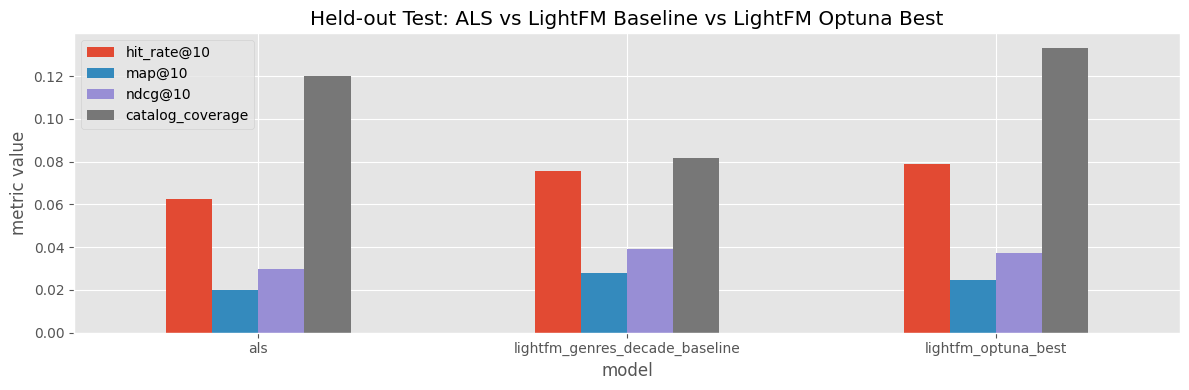

In [31]:
plot_df = test_comparison.set_index("model")[["hit_rate@10", "map@10", "ndcg@10", "catalog_coverage"]]
plot_df.plot(kind="bar", figsize=(12, 4), rot=0, title="Held-out Test: ALS vs LightFM Baseline vs LightFM Optuna Best")
plt.ylabel("metric value")
plt.tight_layout()
plt.show()


## Встроенные графики Optuna

Ниже используются встроенные графики `Optuna`.
Здесь важно не перепутать уровни анализа: эти графики показывают историю оптимизации и важность гиперпараметров, а не важность item-features.


In [32]:
optimization_history_fig = plot_optimization_history(study)
optimization_history_fig.show()

param_importances_fig = plot_param_importances(study)
param_importances_fig.show()

parallel_coordinate_fig = plot_parallel_coordinate(study)
parallel_coordinate_fig.show()


## Как интерпретировать результат

В этом notebook мы уже не улучшаем признаки, а проверяем, сколько качества можно вернуть через настройку модели на фиксированном feature set.

По текущему прогону видно следующее:

- tuned-версия `LightFM` стала лучшей на `validation` и сохранила часть этого выигрыша на held-out `test`;
- на `test` она обгоняет baseline и `ALS` по `precision@10`, `recall@10`, `hit_rate@10` и `catalog coverage`;
- при этом baseline `lightfm_genres_decade` всё ещё лучше по `MAP@10` и `NDCG@10`.

Главный учебный вывод здесь такой:

- tuning действительно помог, а не просто улучшил качество на одном validation-наборе;
- но выигрыш оказался не по всем метрикам сразу;
- если для нас важнее чаще попадать в релевантный объект внутри top-K, tuned-модель выглядит сильнее;
- если важнее более качественный порядок внутри top-K, baseline-конфигурация всё ещё остаётся очень конкурентной.

То есть после tuning выбирать "лучшую модель" нужно не по абстрактной идее "больше параметров = лучше", а по заранее выбранной целевой метрике.


## Что дальше

Следующий шаг в маршруте: [02d_neural_collaborative_filtering.ipynb](/Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/notebooks/advanced/02d_neural_collaborative_filtering.ipynb).

Там мы уже сменим не признаки и не гиперпараметры, а сам класс модели.
